# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [17]:
df = pd.read_csv('../data/checker_submits.csv', sep=',', parse_dates=['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.day_of_week
df = df.drop('timestamp', axis=1)
df.head()

,uid,labname,numTrials,hour,dayofweek
0,user_4,project1,1,5,4
1,user_4,project1,2,5,4
2,user_4,project1,3,5,4
3,user_4,project1,4,5,4
4,user_4,project1,5,5,4


One Hot Encoding — это метод преобразования категориальных данных (городов, цветов, профессий) в числовой формат

In [18]:
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df[['uid', 'labname']])

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['uid', 'labname']))

df_encoded = pd.concat([df[['numTrials', 'hour', 'dayofweek']], encoded_df], axis=1)

df_encoded

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,1,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,9,20,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,6,20,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,7,20,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,8,20,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [19]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df_encoded[['numTrials', 'hour']])

df_encoded[['numTrials', 'hour']] = scaled

In [20]:
df_encoded.to_csv('../data/dayofweek.csv', index=False)

In [21]:
df['dayofweek'].value_counts(normalize=True).max(0)

np.float64(0.23487544483985764)

## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

In [22]:
X = df_encoded.drop('dayofweek', axis=1)
y = df_encoded['dayofweek']

In [23]:
model = OneVsRestClassifier(LogisticRegression(random_state=21, fit_intercept=False))
model.fit(X, y)

y_pred = model.predict(X)
accuracy_score(y_pred=y_pred, y_true=y)

0.6209964412811388

In [24]:
def plot_top_features(model, feature_names, top=10):
    # hasattr - есть ли у объекта заданный атрибут
    if hasattr(model, "coef_"): 
        coefs = model.coef_
        importance = np.sum(np.abs(coefs), axis=0)      # суммируем коэф -> важность
    elif hasattr(model, "estimators_") and hasattr(model.estimators_[0], "coef_"):  
        coefs = np.array([est.coef_.ravel() for est in model.estimators_])
        importance = np.sum(np.abs(coefs), axis=0)
    elif hasattr(model, "feature_importances_"):  
        importance = model.feature_importances_

    indices = np.argsort(importance)[-top:]     # np.argsort() - возвращает индексы элементов массива
    top_features = np.array(feature_names)[indices]     # массив названий признаков
    top_importance = importance[indices]        # массив ЗНАЧЕНИЙ признаков

    plt.figure(figsize=(12, 8))
    plt.barh(top_features, top_importance, color='steelblue')
    plt.title(f"Top {top} most important features")
    plt.tight_layout()
    plt.show()
 

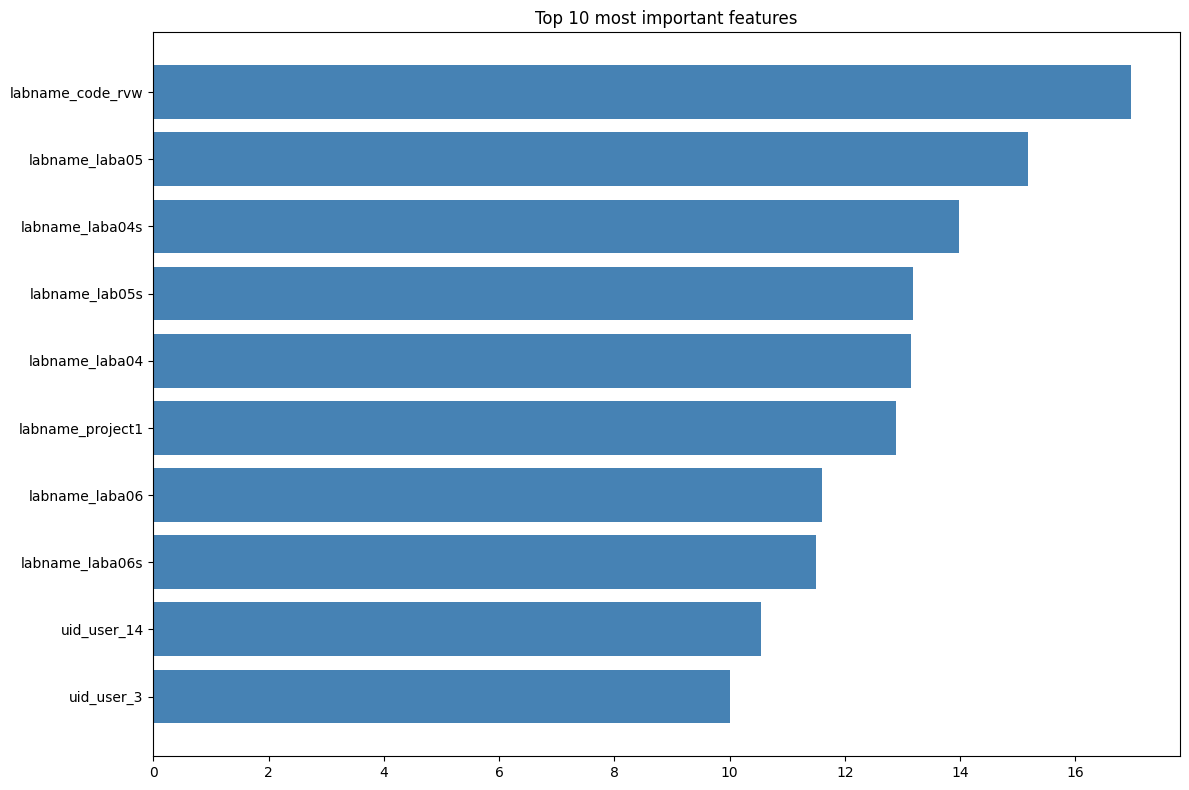

In [25]:
plot_top_features(model, X.columns, top=10)

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

- По умолчанию SVC использует стратегию One-vs-One (OvO) для многоклассовой классификации.
- OneVsRestClassifier обучает одну модель на каждый класс (против всех остальных).

In [26]:
model = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=21))
model.fit(X, y)

y_pred = model.predict(X)
accuracy_score(y_pred, y)

0.6126927639383155

In [27]:
kernels = ['poly', 'rbf', 'sigmoid']
accuracies = {}

for k in kernels:
    model_tr = SVC(kernel=k, probability=True, random_state=21)
    model_tr.fit(X, y)
    y_pred = model_tr.predict(X)
    acc = accuracy_score(y_pred, y)
    accuracies[k] = acc

print("Accuracies by kernel:")
for k, v in accuracies.items():
    print(f"{k}: {v:.4f}")

Accuracies by kernel:
poly: 0.8594
rbf: 0.8559
sigmoid: 0.3998


- OneVsRestClassifier хранит обученные модели в model.estimators_

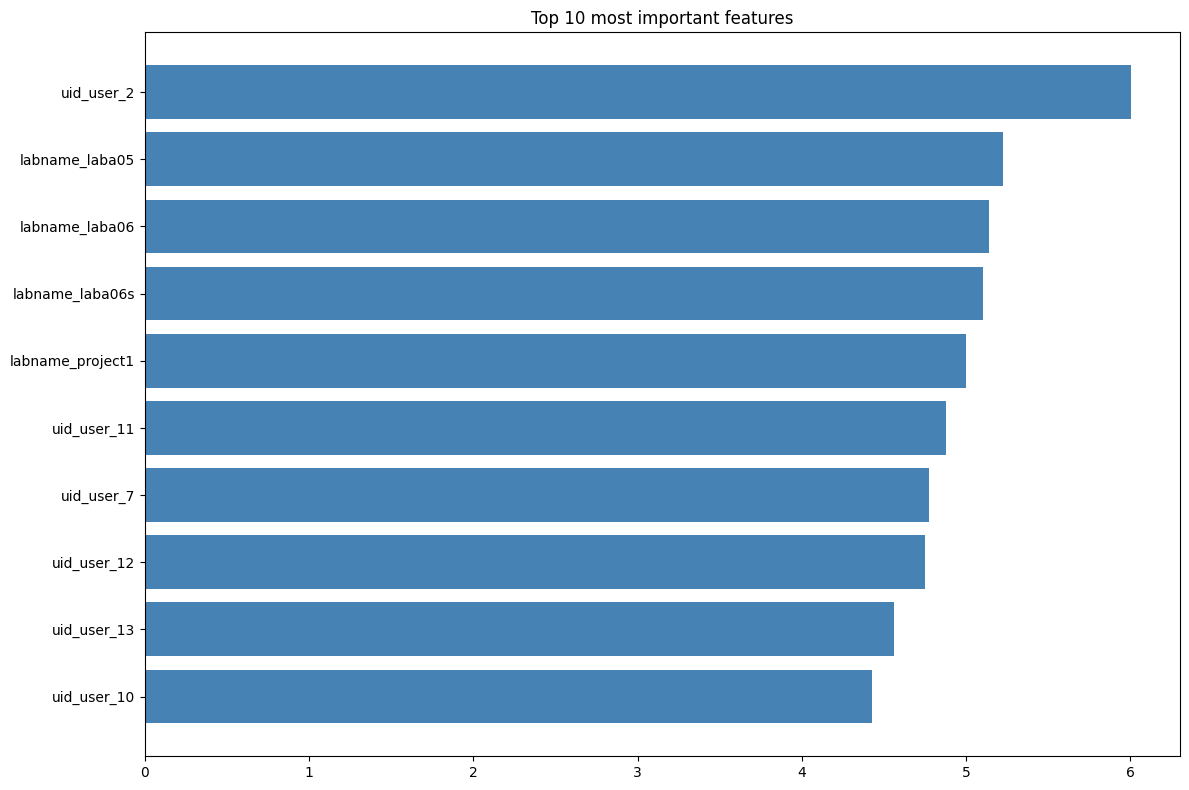

In [28]:
plot_top_features(model, X.columns, top=10)

### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [29]:
model = DecisionTreeClassifier(max_depth=4, random_state=21)
model.fit(X,y)
y_pred = model.predict(X)
accuracy_score(y_pred,y)

0.5516014234875445

In [30]:
for depth in range(1,10):
    model_tr = DecisionTreeClassifier(max_depth=depth, random_state=21)
    model_tr.fit(X,y)
    y_pred = model_tr.predict(X)
    print(f"Depth={depth}, Accuracy={accuracy_score(y_pred, y):.3f}")

Depth=1, Accuracy=0.358
Depth=2, Accuracy=0.439
Depth=3, Accuracy=0.490
Depth=4, Accuracy=0.552
Depth=5, Accuracy=0.611
Depth=6, Accuracy=0.664
Depth=7, Accuracy=0.706
Depth=8, Accuracy=0.750
Depth=9, Accuracy=0.785


In [31]:
model.feature_importances_

array([0.14931603, 0.06154574, 0.        , 0.        , 0.        ,
       0.        , 0.09837711, 0.        , 0.06455791, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.07642063,
       0.        , 0.        , 0.        , 0.        , 0.01610628,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.06154768, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.05479407, 0.        , 0.08646791,
       0.        , 0.05629871, 0.27456793])

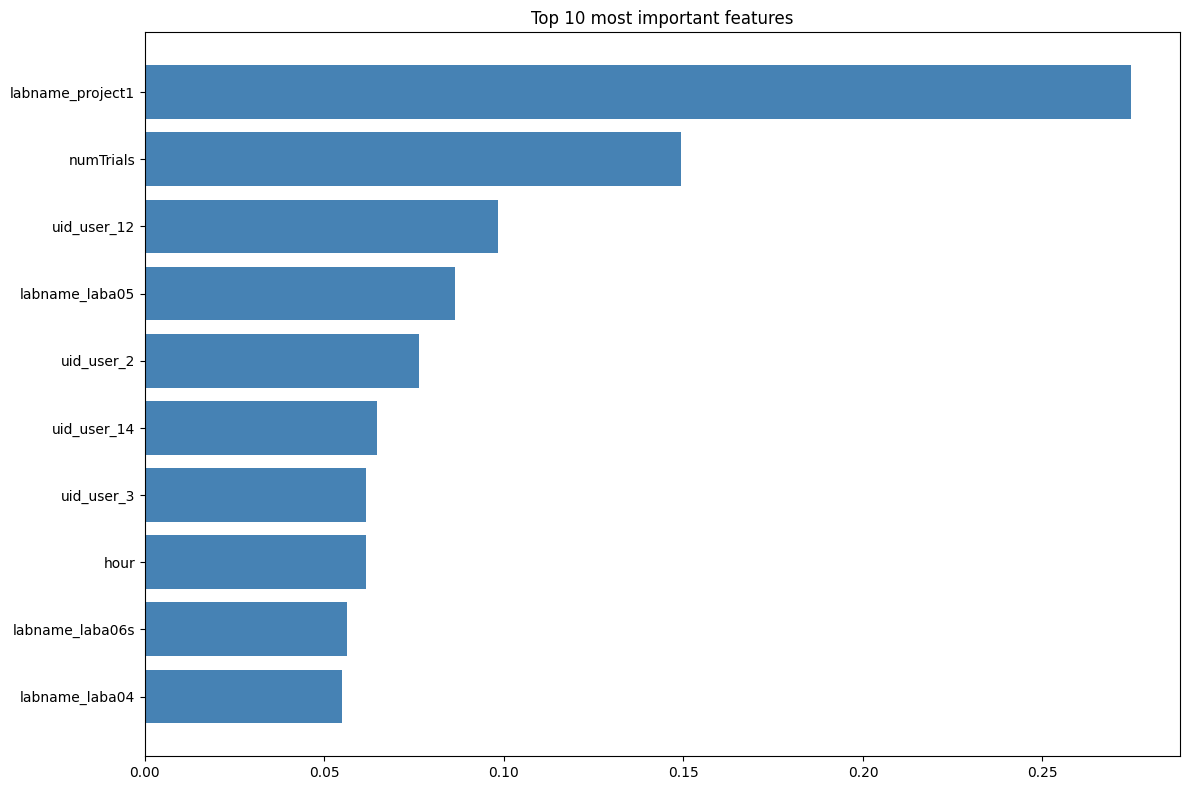

In [32]:
plot_top_features(model, X.columns, top=10)

### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [33]:
model = RandomForestClassifier(n_estimators=100, max_depth = 25, random_state=21)
model.fit(X, y)

,n_estimators,100
,criterion,'gini'
,max_depth,25
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
y_pred = model.predict(X)
accuracy_score(y_pred, y)

1.0

In [35]:
for depth in range(10,30, 5):
    for est in range(50, 150, 30):
        model_tr = RandomForestClassifier(n_estimators=est, max_depth = depth, random_state=21)
        model_tr.fit(X,y)
        y_pred = model_tr.predict(X)
        print(f"Depth={depth}, n_estimators={est}, Accuracy={accuracy_score(y_pred, y):.3f}")

Depth=10, n_estimators=50, Accuracy=0.870
Depth=10, n_estimators=80, Accuracy=0.878
Depth=10, n_estimators=110, Accuracy=0.884
Depth=10, n_estimators=140, Accuracy=0.884
Depth=15, n_estimators=50, Accuracy=0.979
Depth=15, n_estimators=80, Accuracy=0.979
Depth=15, n_estimators=110, Accuracy=0.979
Depth=15, n_estimators=140, Accuracy=0.980
Depth=20, n_estimators=50, Accuracy=0.997
Depth=20, n_estimators=80, Accuracy=0.995
Depth=20, n_estimators=110, Accuracy=0.996
Depth=20, n_estimators=140, Accuracy=0.998
Depth=25, n_estimators=50, Accuracy=1.000
Depth=25, n_estimators=80, Accuracy=1.000
Depth=25, n_estimators=110, Accuracy=0.999
Depth=25, n_estimators=140, Accuracy=1.000


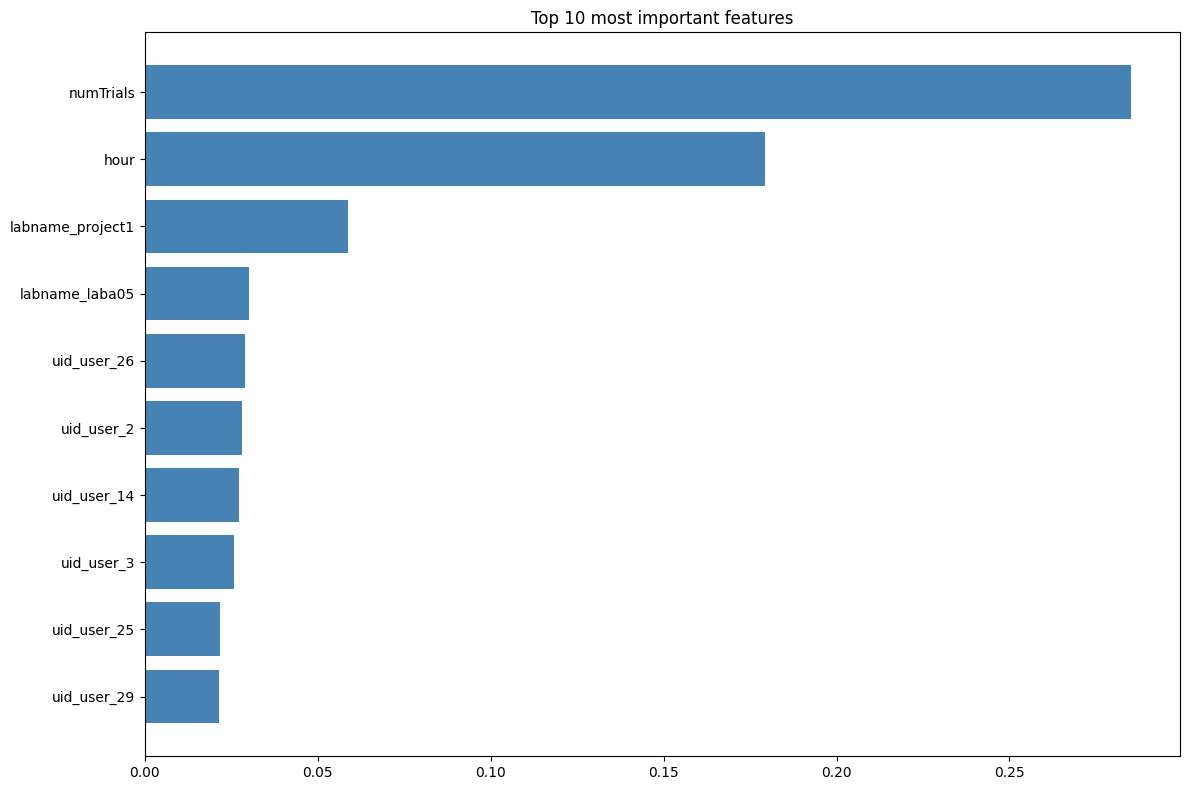

In [36]:
plot_top_features(model, X.columns, top=10)